# ***Projet Machine Learning : Prédiction du prix de vente des véhicules d'occasion***
##Safa Ben Salha 1ère année de Master de Recherche en Business Computing
##**Présentation de la problématique:**
Sur le marché de l'automobile d'occasion, la fixation du prix de vente reste un défi tant pour les particuliers que pour les professionnels. La valeur d'un véhicule dépend d'une multitude de facteurs corrélés, allant de ses spécifications techniques (puissance, type de carburant) à son historique d'utilisation (kilométrage, nombre de propriétaires).

L'objectif de ce projet est de concevoir un modèle de Machine Learning capable de prédire avec précision le prix de vente d'un véhicule d'occasion. En automatisant cette estimation, nous visons à réduire l'asymétrie d'information entre acheteurs et vendeurs, tout en fournissant un outil d'aide à la décision fiable pour les transactions automobiles.
##**État de l'art : Méthodes de prédiction des prix automobiles**
###**La Régression Linéaire :**
C'est la méthode statistique fondamentale utilisée pour établir une relation linéaire entre les caractéristiques techniques d'un véhicule (kilométrage, année) et son prix de vente. Elle sert de modèle de référence (baseline) pour comparer les performances des modèles plus complexes.

**Source** : https://www.researchgate.net/publication/371171222_Used_Car_Price_Prediction_Using_Machine_Learning

###**Les Arbres de Décision (Decision Trees) :**
Cette méthode segmente les données en créant des règles logiques hiérarchiques (ex: si puissance > 100ch, alors prix élevé). Elle permet une interprétation visuelle claire du processus de décision du modèle.

**Source**: https://www.researchgate.net/publication/371171222_Used_Car_Price_Prediction_Using_Machine_Learning

###**Le Random Forest :**
Il s'agit d'une méthode d'ensemble puissante qui combine plusieurs arbres de décision pour obtenir une prédiction plus stable et précise. C'est l'un des algorithmes les plus recommandés dans la littérature pour sa capacité à gérer des données variées sans surapprentissage.

**Source**:https://www.researchgate.net/publication/356756110_Price_Prediction_for_Pre-Owned_Cars_Using_Ensemble_Machine_Learning_Techniques

###**Le K-Nearest Neighbors (KNN) :**
Le KNN repose sur le principe de similarité : pour prédire le prix d'un véhicule, l'algorithme identifie les véhicules les plus proches (voisins) dans le dataset et calcule la moyenne de leurs prix. C'est une approche intuitive et efficace pour capturer les tendances locales du marché.

**Source**: https://www.researchgate.net/publication/371722476_A_SURVEY_ON_USED_VEHICLE_PRICE_ESTIMATION_SYSTEMS_USING_ARTIFICIAL_INTELLIGENCE_METHODS
##**Analyse des méthodes de Machine Learning choisies**
Pour prédire le prix des véhicules d'occasion, nous avons implémenté quatre approches distinctes. Voici l'analyse détaillée de chaque méthode :

###**1. La Régression Linéaire (Linear Regression)**
La régression linéaire est notre modèle de référence (baseline). Elle repose sur l'hypothèse qu'il existe une relation linéaire entre les caractéristiques du véhicule (comme l'année ou le kilométrage) et son prix. L'algorithme cherche à tracer la "droite" qui minimise l'écart entre les prédictions et les prix réels. C'est une méthode indispensable pour comprendre l'impact direct de chaque variable sur la valeur marchande.

###**2. Le K-Nearest Neighbors (KNN)**
Le KNN apporte une dimension locale à notre analyse. Contrairement à la régression qui cherche une tendance globale, ce modèle examine les caractéristiques des voitures les plus comparables dans notre jeu de données pour estimer le prix. Cette approche est particulièrement pertinente pour capturer des "segments" de marché où le prix évolue de manière spécifique, offrant ainsi une perspective différente des modèles purement mathématiques.

###**3. Les Arbres de Décision (Decision Tree)**
Les arbres de décision agissent comme un système de filtres successifs. Pour notre étude, ce modèle permet de décomposer le processus de valorisation en une série de choix logiques basés sur les attributs du véhicule. C'est un outil précieux pour valider les hiérarchies de critères, car il révèle clairement les seuils (par exemple, des tranches d'année ou de puissance) qui entraînent les variations les plus significatives sur le prix de vente final.

###**4. Le Random Forest (Forêt Aléatoire)**
Le Random Forest est une méthode d'apprentissage d'ensemble qui consiste à construire une multitude d'arbres de décision sur différents sous-ensembles du dataset. En faisant la moyenne des résultats de tous ces arbres, le modèle devient beaucoup plus robuste et moins sensible aux valeurs aberrantes. Dans notre projet, il permet de capturer des interactions complexes entre les options du véhicule que les modèles simples ne peuvent pas détecter.



## **Implémentation, simulation et résultats**

Cette section présente la mise en œuvre technique du projet. Nous y détaillons les étapes de traitement, allant du nettoyage des données jusqu'à l'entraînement et l'évaluation comparative des modèles de Machine Learning sélectionnés. Pour mesurer leur fiabilité, nous avons procédé à une simulation sur une partie isolée de notre dataset. Ces données sont restées 'cachées' lors de l'entraînement, garantissant ainsi une évaluation objective de la capacité de généralisation de chaque méthode. Les résultats permettent une comparaison transparente entre la régression linéaire, le KNN, les arbres de décision et le Random Forest, illustrant leurs comportements respectifs face à la complexité du marché automobile.

###**Pré-traitement et nettoyage des données :**


In [ ]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv('Car details v3.csv')

# Nettoyage robuste : on extrait les chiffres et on force la conversion en nombre
# Si une valeur n'est pas un nombre, elle devient NaN (valeur manquante)
df['mileage'] = pd.to_numeric(df['mileage'].str.replace(r'[^\d.]+', '', regex=True), errors='coerce')
df['engine'] = pd.to_numeric(df['engine'].str.replace(r'[^\d.]+', '', regex=True), errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'].str.replace(r'[^\d.]+', '', regex=True), errors='coerce')

# Suppression des lignes où il manque des données (ceux qu'on a transformés en NaN)
df = df.dropna()

# Encodage des données catégorielles
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)

print("Nettoyage réussi !")
display(df.head())

Nettoyage réussi !


,name,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti Swift Dzire VDI,2014,450000,145500,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,True,False,False,True,False,True,False,False,False,False
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,True,False,False,True,False,True,False,True,False,False
2,Honda City 2017-2020 EXi,2006,158000,140000,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,False,False,True,True,False,True,False,False,False,True
3,Hyundai i20 Sportz Diesel,2010,225000,127000,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,True,False,False,True,False,True,False,False,False,False
4,Maruti Swift VXI BSIII,2007,130000,120000,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,False,False,True,True,False,True,False,False,False,False


###**Initialisation et entraînement des algorithmes :**



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Préparation : on supprime 'torque' en plus de 'name' et 'selling_price'
X = df.drop(['name', 'selling_price', 'torque'], axis=1)
y = df['selling_price']

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement des 4 modèles
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Entraînement des 4 modèles terminé avec succès !")

Entraînement des 4 modèles terminé avec succès !


###**Évaluation des performances des modèles :**


In [ ]:
# Prédictions
y_pred_lr = model_lr.predict(X_test)
y_pred_knn = model_knn.predict(X_test)
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Affichage des performances
print("--- Résultats de la comparaison ---")
models = [("Régression Linéaire", y_pred_lr), ("KNN", y_pred_knn), ("Decision Tree", y_pred_dt), ("Random Forest", y_pred_rf)]
for name, pred in models:
    print(f"{name} | MAE: {mean_absolute_error(y_test, pred):.2f} | R2: {r2_score(y_test, pred):.2f}")



--- Résultats de la comparaison ---
Régression Linéaire | MAE: 271260.12 | R2: 0.69
KNN | MAE: 166606.75 | R2: 0.82
Decision Tree | MAE: 75342.71 | R2: 0.96
Random Forest | MAE: 61101.79 | R2: 0.98


###**Illustration des prédictions sur des cas réels :**





In [ ]:
# Sélectionner 5 exemples du jeu de test
exemples = X_test.head(5).copy()
exemples['Prix Réel'] = y_test.head(5).values

# Ajouter les prédictions de chaque modèle
exemples['Linéaire'] = model_lr.predict(X_test.head(5))
exemples['KNN'] = model_knn.predict(X_test.head(5))
exemples['Decision Tree'] = model_dt.predict(X_test.head(5))
exemples['Random Forest'] = model_rf.predict(X_test.head(5))

# Afficher le résultat
print("Comparaison concrète des prédictions par modèle :")
display(exemples[['Prix Réel', 'Linéaire', 'KNN', 'Decision Tree', 'Random Forest']])

Comparaison concrète des prédictions par modèle :


,Prix Réel,Linéaire,KNN,Decision Tree,Random Forest
3756,501000,6.500671e+05,419200.0,650000.0,566239.960000
5692,440000,4.322472e+05,536999.8,510000.0,518153.333333
3637,140000,6.846913e+04,541000.0,168000.0,166009.970000
7693,476999,5.093749e+05,437000.0,600000.0,382239.980000
3565,620000,1.078822e+06,580000.0,620000.0,586678.521429


###**Visualisation graphique de la précision des modèles:**





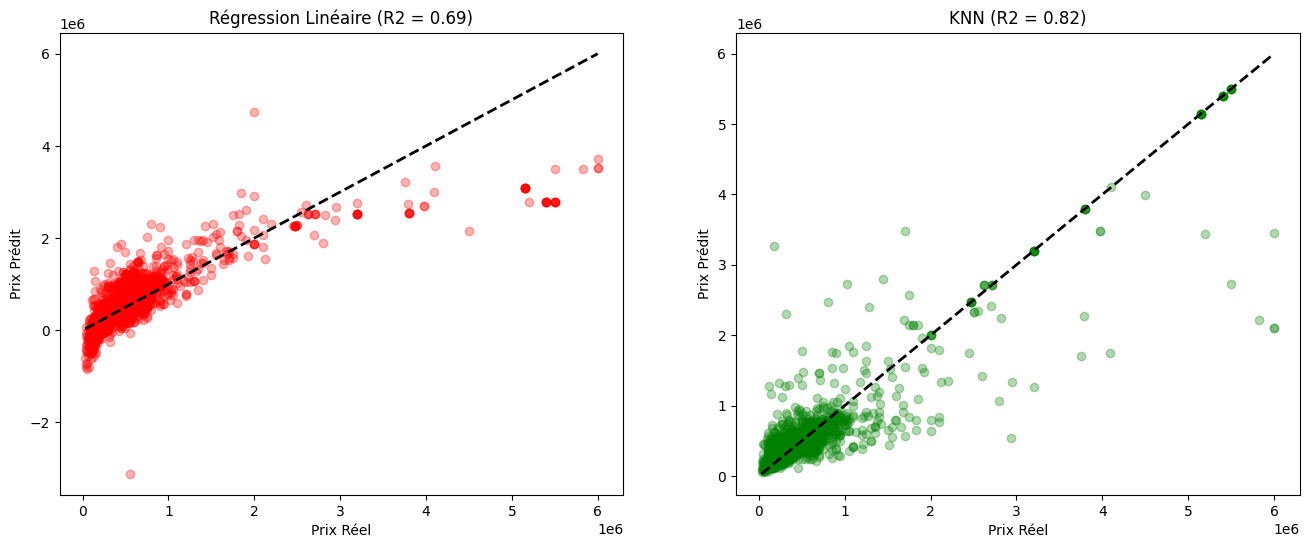

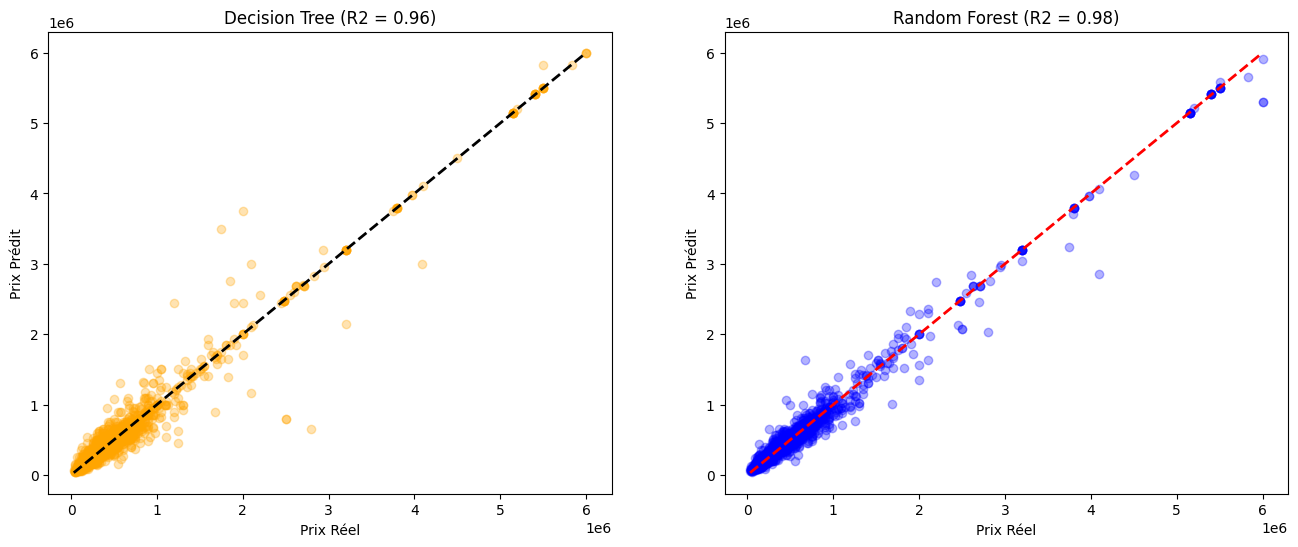

In [ ]:
# Première ligne : Régression Linéaire et KNN
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

axes1[0].scatter(y_test, y_pred_lr, alpha=0.3, color='red')
axes1[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes1[0].set_title("Régression Linéaire (R2 = 0.69)")
axes1[0].set_xlabel("Prix Réel")
axes1[0].set_ylabel("Prix Prédit")

axes1[1].scatter(y_test, y_pred_knn, alpha=0.3, color='green')
axes1[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes1[1].set_title("KNN (R2 = 0.82)")
axes1[1].set_xlabel("Prix Réel")
axes1[1].set_ylabel("Prix Prédit")
plt.show()

# Deuxième ligne : Decision Tree et Random Forest
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

axes2[0].scatter(y_test, y_pred_dt, alpha=0.3, color='orange')
axes2[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes2[0].set_title("Decision Tree (R2 = 0.96)")
axes2[0].set_xlabel("Prix Réel")
axes2[0].set_ylabel("Prix Prédit")

axes2[1].scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
axes2[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes2[1].set_title("Random Forest (R2 = 0.98)")
axes2[1].set_xlabel("Prix Réel")
axes2[1].set_ylabel("Prix Prédit")
plt.show()

##**Analyse des résultats et précision de prédiction:**
###**Régression Linéaire:**
Le modèle de régression linéaire présente un score $R^2$ de 0.69 et une erreur MAE de [271260.12]. Sur le graphique ci-dessous, on observe une dispersion marquée des points autour de la diagonale idéale. Si le modèle capte la tendance globale du marché, les écarts visibles, particulièrement pour les valeurs élevées, illustrent la difficulté de cette approche à modéliser les relations non-linéaires complexes du secteur automobile.
###**K-Nearest Neighbors (KNN):**
 L'approche par voisinage améliore la précision ($R^2 = 0.82$). En se basant sur la proximité des données, il capte mieux les spécificités locales, bien que sa performance reste limitée par sa sensibilité au bruit des données.
###**Decision Tree :**
 Ce modèle marque un tournant majeur ($R^2 = 0.96$). En structurant les décisions sous forme d'arborescence, il s'adapte avec finesse aux variations du prix, réduisant drastiquement l'erreur MAE par rapport aux approches précédentes.
###**Random Forest**
Le Random Forest affiche des performances nettement supérieures avec un score $R^2$ de 0.98 et une erreur MAE de [61101.79]. Le graphique montre une forte corrélation entre les valeurs prédites et réelles, la majorité des points étant alignés sur la diagonale. Les légères dispersions aux extrémités confirment la capacité du modèle à généraliser tout en pondérant efficacement les cas complexes.

##**Analyse comparative détaillée des méthodes choisies**
Cette comparaison met en lumière la limite des modèles linéaires face à la complexité des données automobiles. En testant quatre approches distinctes, nous démontrons que les modèles basés sur les arbres de décision sont les plus efficaces pour capturer fidèlement la réalité du marché et garantir des prédictions précises.

In [ ]:
# Tableau comparatif  avec les 4 modèles
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'KNN', 'Decision Tree', 'Random Forest'],
    'Erreur MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_knn),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'Score R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_knn),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print("Tableau comparatif des performances :")
display(results)

Tableau comparatif des performances :


,Modèle,Erreur MAE,Score R2
0,Régression Linéaire,271260.123659,0.687191
1,KNN,166606.754614,0.819247
2,Decision Tree,75342.709440,0.961424
3,Random Forest,61101.793786,0.983600


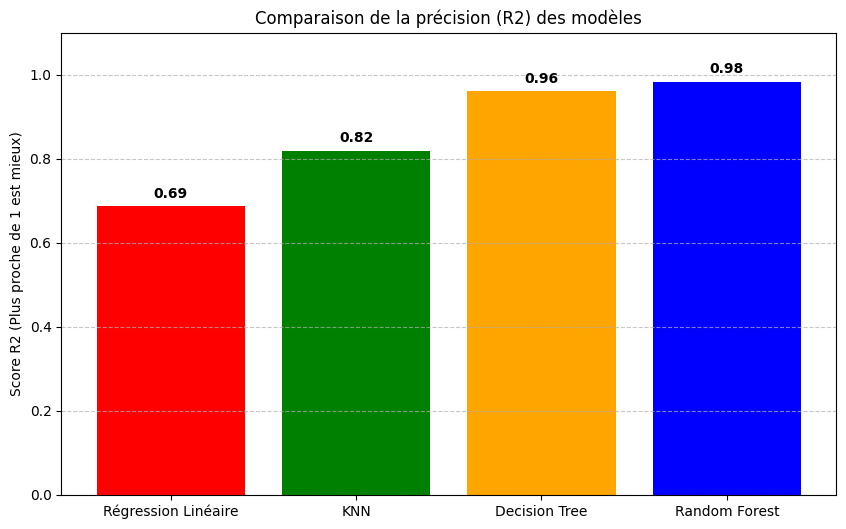

In [ ]:
import matplotlib.pyplot as plt

# Graphique comparatif des scores R2
plt.figure(figsize=(10, 6))
# On utilise une liste de 4 couleurs pour correspondre aux 4 modèles
colors = ['red', 'green', 'orange', 'blue']

plt.bar(results['Modèle'], results['Score R2'], color=colors)

plt.title('Comparaison de la précision (R2) des modèles')
plt.ylabel('Score R2 (Plus proche de 1 est mieux)')
plt.ylim(0, 1.1)  # Pour bien voir la progression vers 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Affichage des valeurs au-dessus des barres pour plus de clarté
for i, v in enumerate(results['Score R2']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

L'étude comparative révèle une progression nette de la précision à mesure que nous augmentons la complexité algorithmique :
###**Gain de performance :**
 Le passage d'une approche linéaire (Régression Linéaire) à des méthodes basées sur les arbres (Decision Tree et Random Forest) engendre une amélioration drastique des résultats. Le tableau démontre que le Random Forest capte la quasi-totalité de la variance du prix ($R^2=0.98$), réduisant l'erreur MAE de façon significative par rapport au modèle de référence.
###**Fiabilité et robustesse :**
 Comme l'illustrent le tableau et le graphique, la régression linéaire et le KNN se heurtent à un plafond de performance structurel. À l'inverse, les modèles basés sur les arbres de décision s'imposent comme des solutions bien plus robustes, capables de modéliser avec précision les disparités complexes du marché automobile."

## **Analyse approfondie des variables influentes:**


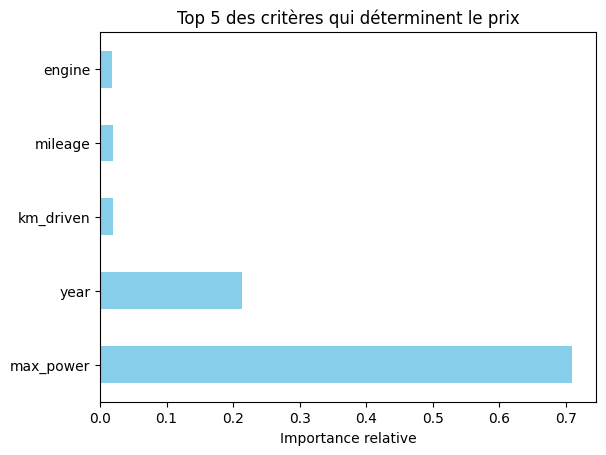

In [ ]:
# Affichage des critères les plus importants pour le modèle Random Forest
feature_importances = pd.Series(model_rf.feature_importances_, index=X.columns)
feature_importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Top 5 des critères qui déterminent le prix')
plt.xlabel('Importance relative')
plt.show()

Ce graphique met en lumière les leviers déterminants dans l'estimation de la valeur d'un véhicule. Il démontre que **la puissance maximale (max power)** et **l'année** de mise en circulation constituent les variables les plus influentes, suivies de manière plus modérée par **le kilométrage**. Cette hiérarchie confirme que notre modèle a appris à prioriser les facteurs techniques et temporels qui structurent réellement le marché automobile, validant ainsi la pertinence de la stratégie de modélisation retenue.

##**Conclusion:**
En conclusion, cette étude démontre que la précision des prédictions de prix dépend étroitement de la capacité des algorithmes à modéliser la complexité du marché. Si les modèles linéaires et basés sur la similarité offrent une base d'analyse utile, les méthodes par arbres de décision, et plus particulièrement le Random Forest, se révèlent nettement plus performantes. En capturant les relations non-linéaires entre les caractéristiques techniques et la valeur vénale des véhicules, notre approche confirme la supériorité des modèles d'ensemble pour fiabiliser l'estimation automobile et soutenir la prise de décision sur ce marché dynamique.